# Supply Chain & Logistics Analysis

## Problem:
Delays in shipment harm operations, customer satisfaction, and revenue. This project identifies key delay factors and suggests logistics optimization strategies.

## Key Questions:
- What causes shipment delays? (Warehouse, shipping mode, discounts)
- Do discounts lead to more delays?
- Which shipping methods are most reliable?
- Do high-priority items face more delays?
- Are delays tied to customer service calls?
- How do delays affect ratings?
- Does weight impact delivery time?

## Methodology:
### Preprocessing:
- Loaded, cleaned, and explored data (missing values, types, duplicates).
  
### EDA & Visuals:
- Analyzed delay distributions, warehouse/shipping modes, discount effects.
- Visual tools: heatmaps, boxplots, bar charts.

### Tools:
Python, Pandas, Jupyter, Seaborn, Matplotlib, Excel (optional).

## Key Findings:
- 📦 **Discounts ↔ Delays:** Heavily discounted items often delayed.
- 📞 **Service Calls:** More calls for expensive/discounted items.
- 🏢 **Warehouse F:** Handles most shipments; operational inefficiencies likely.
- 🚚 **High Importance = More Delays:** Possibly due to special handling.
- ⚖️ **Weight Factor:** Lighter items delayed more often.
- 💸 **Cost ≠ Speed:** Price doesn’t guarantee faster shipping.
- ⭐ **Customer Ratings:** Delays hurt ratings but not the only factor.

## Recommendations:
- Improve handling of discounted and priority products.
- Enhance shipment tracking and transparency.
- Investigate logistics in Warehouse F and shipping modes.
- Address lightweight shipping inefficiencies.
- Offset delay impact with better customer experience strategies.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "shipping.csv"
df = pd.read_csv(file_path)

df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


# Conclusions from the primary analysis:
**- No missing values**.

**- No duplicates**.

**- Average customer rating 3**.

In [4]:
# Check for missing values
missing_values = df.isnull().sum()

# Check for duplicates
duplicate_rows = df.duplicated().sum()

# Basic statistics
data_summary = df.describe()
missing_values, duplicate_rows, data_summary

(ID                     0
 Warehouse_block        0
 Mode_of_Shipment       0
 Customer_care_calls    0
 Customer_rating        0
 Cost_of_the_Product    0
 Prior_purchases        0
 Product_importance     0
 Gender                 0
 Discount_offered       0
 Weight_in_gms          0
 Reached.on.Time_Y.N    0
 dtype: int64,
 0,
                 ID  Customer_care_calls  Customer_rating  Cost_of_the_Product  \
 count  10999.00000         10999.000000     10999.000000         10999.000000   
 mean    5500.00000             4.054459         2.990545           210.196836   
 std     3175.28214             1.141490         1.413603            48.063272   
 min        1.00000             2.000000         1.000000            96.000000   
 25%     2750.50000             3.000000         2.000000           169.000000   
 50%     5500.00000             4.000000         3.000000           214.000000   
 75%     8249.50000             5.000000         4.000000           251.000000   
 max    10999

# Business Insights from correlation matrix

***1. High Discounts = High Delays 📉***→ If reducing delays is a priority, the company might reconsider how discounted products are handled in logistics.

***2. Customer Service Load 📞 →*** Expensive products and discounted orders generate more calls. Improving tracking and transparency could reduce inquiries.

***3. Optimizing Warehouse & Shipping 🚚 →*** Analyzing why certain warehouses or shipping methods cause delays can help improve supply chain efficiency.

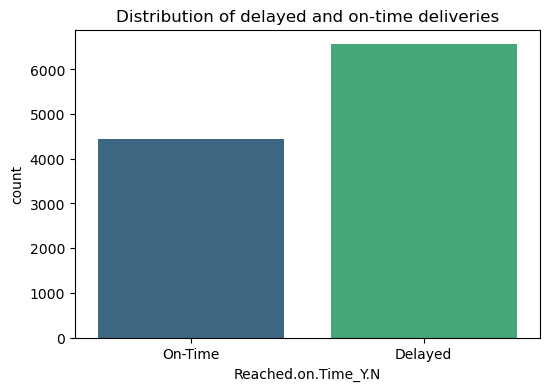

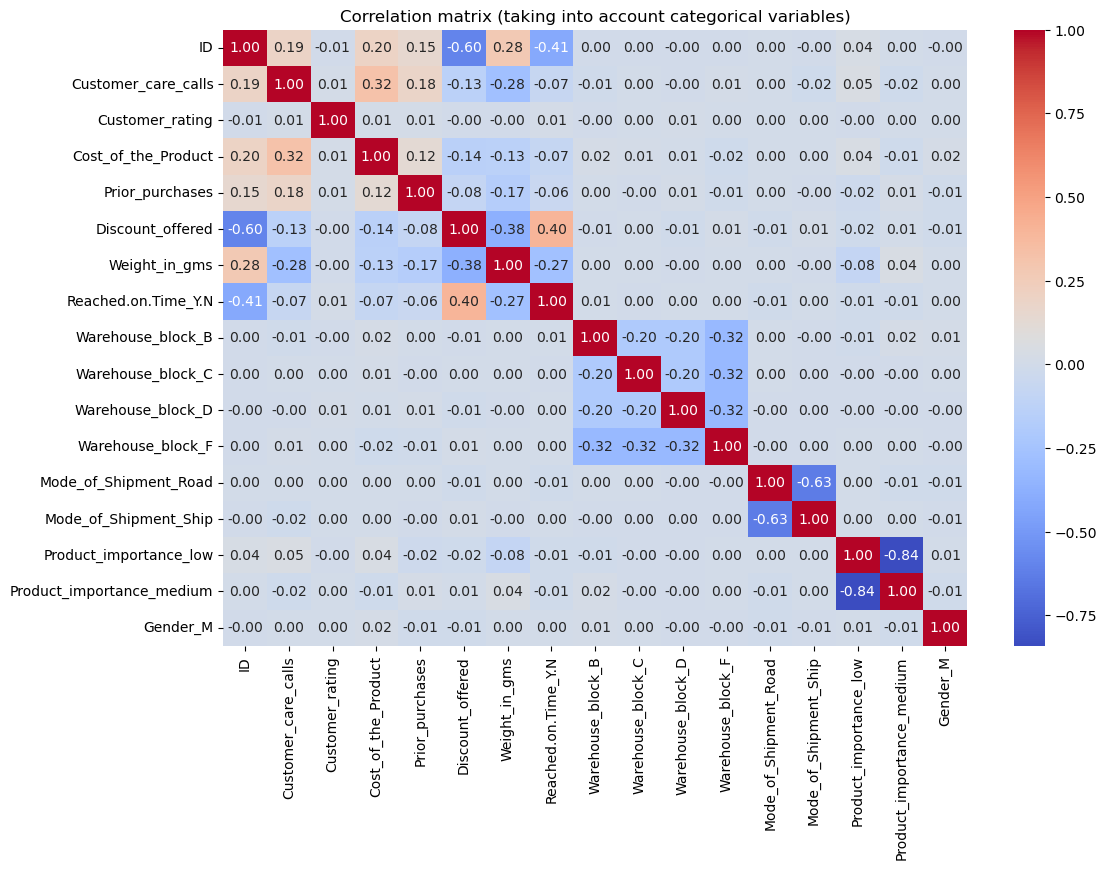

In [6]:
# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Reached.on.Time_Y.N"], hue=df["Reached.on.Time_Y.N"], palette="viridis", legend=False)
plt.title("Distribution of delayed and on-time deliveries")
plt.xticks([0, 1], ["On-Time", "Delayed"])
plt.show()

# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"], drop_first=True)

# Construction of a correlation matrix taking into account categorical variables
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix (taking into account categorical variables)")
plt.show()

# Analysis of categorical variables:

***1️. Warehouse Block*** – Most shipments go through Block F, while others are evenly distributed.

***2️. Mode of Shipment*** – Ship is the dominant method, while Flight and Road are less used.

***3️. Product Importance*** – Majority of shipments are low or medium importance; high is rare.

***4️. Gender*** – Orders are evenly split between males and females.

## Potential Insights:
***- Optimize warehouse load (Why is Block F dominant?)***

***- Evaluate shipping efficiency (Is Ship the best option?)***

***- Adjust product strategy (Why are high-importance products rare?)***

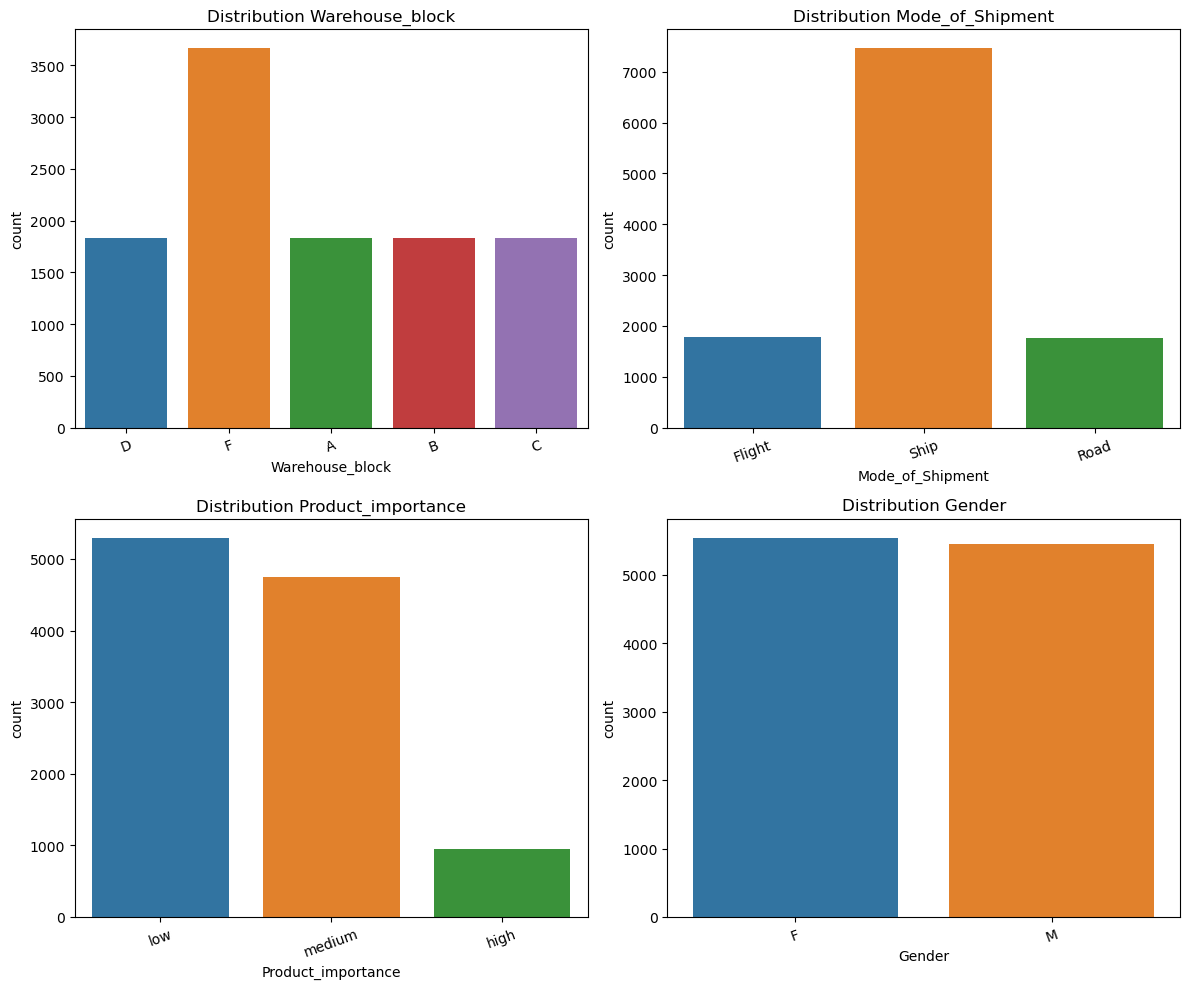

In [8]:
categorical_columns = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    sns.countplot(x=df[col], ax=axes[i], hue=df[col], legend=False) 
    axes[i].set_title(f"Distribution {col}")
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [9]:
#Get the average, minimum, maximum value, and spread of the data.

numerical_columns = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
                     "Prior_purchases", "Discount_offered", "Weight_in_gms"]

df[numerical_columns].describe()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729
std,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000
25%,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000


# Distribution of numeric variables

***1️. Customer Care Calls*** – Most customers make 4-5 calls, with a max of 7.

***2️. Customer Ratingx*** – Average rating is ~3, with a range from 1 to 5.

***3️. Cost of Product*** – Prices vary widely (96 to 310), with an average of 210.

***4️. Prior Purchases*** – Most customers have 2-4 past purchases, max 10.

***5️. Discount Offered*** – Discounts are highly variable, from 1 to 65%.

***6️. Weight in gms*** – Product weights range from 1001g to 7846g, with an average of 3634g.

## Possible Insights:
***- High discount variation*** —could impact profit margins.

***- Customer rating is low*** —potential quality/service issues.

***- Most purchases are repeat orders*** —loyal customer base?

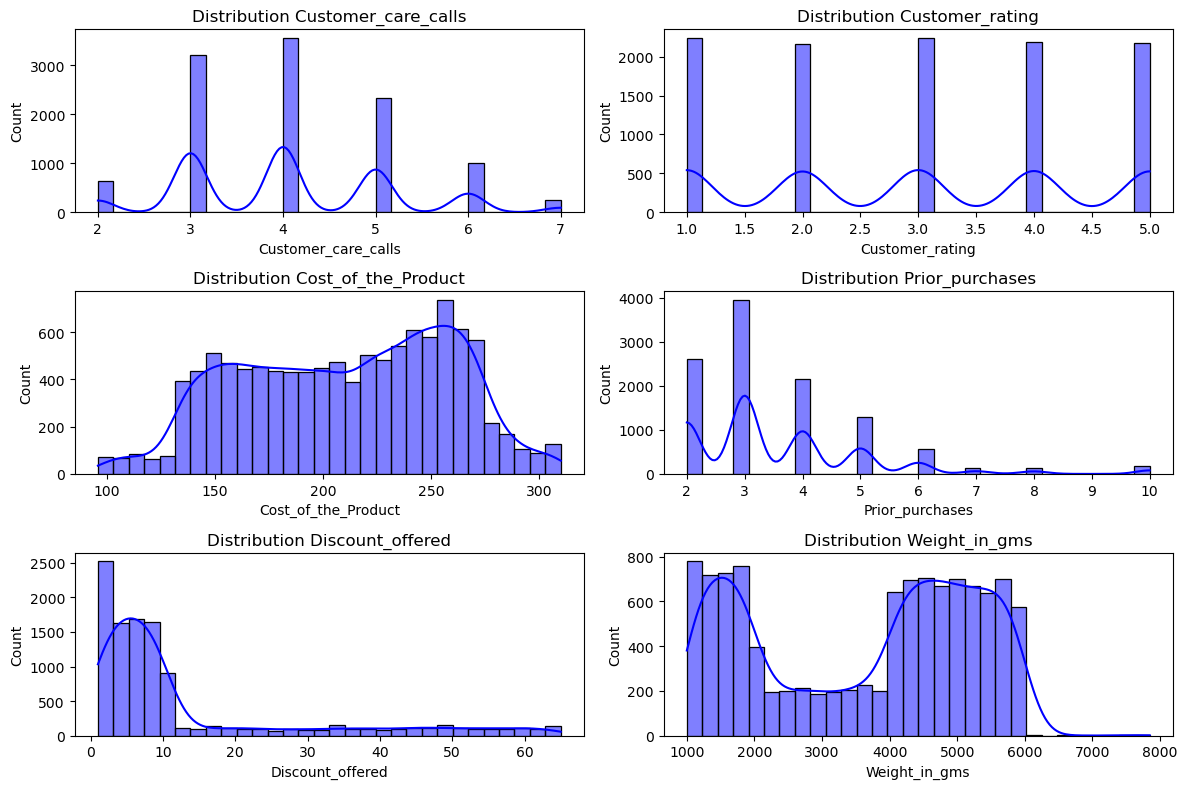

In [11]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], bins=30, kde=True, color="blue")
    plt.title(f"Distribution {col}")
    
plt.tight_layout()
plt.show()

# Contribution of warehouses

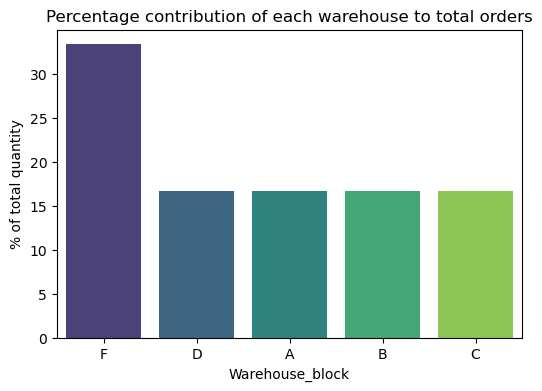

Warehouse_block
F    33.330303
D    16.674243
A    16.665151
B    16.665151
C    16.665151
Name: proportion, dtype: float64


In [13]:
warehouse_counts = df["Warehouse_block"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=warehouse_counts.index, y=warehouse_counts.values, hue=warehouse_counts.index, palette="viridis", legend=False)
plt.title("Percentage contribution of each warehouse to total orders")
plt.ylabel("% of total quantity")
plt.show()

print(warehouse_counts)

# Contribution of delivery methods

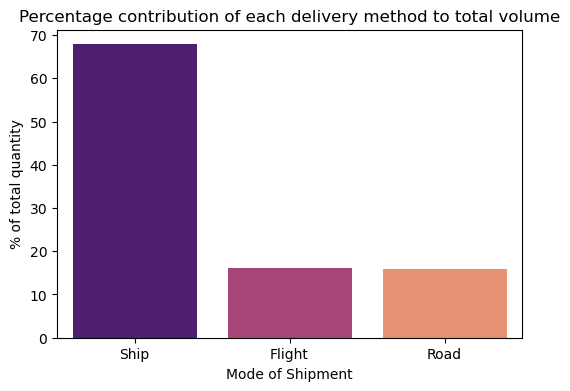

Mode_of_Shipment
Ship      67.842531
Flight    16.156014
Road      16.001455
Name: proportion, dtype: float64


In [15]:
shipment_counts = df["Mode_of_Shipment"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=shipment_counts.index, y=shipment_counts.values, hue=shipment_counts.index, palette="magma", legend=False)
plt.title("Percentage contribution of each delivery method to total volume")
plt.ylabel("% of total quantity")
plt.xlabel("Mode of Shipment")
plt.show()

print(shipment_counts)

# Proportion of delays from all orders for each delivery method

This suggests that no single shipping method significantly outperforms the others in terms of on-time delivery, and delays may be influenced by other factors such as warehouse efficiency or product importance.


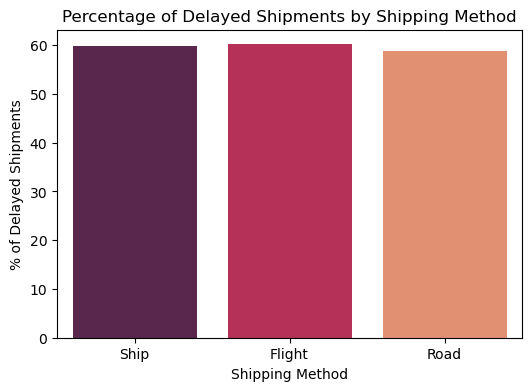

Mode_of_Shipment
Ship      59.756098
Flight    60.157569
Road      58.806818
Name: count, dtype: float64


In [17]:
# Calculate the total number of orders for each shipping method
total_shipments = df["Mode_of_Shipment"].value_counts()
delayed_shipments = df[df["Reached.on.Time_Y.N"] == 1]["Mode_of_Shipment"].value_counts()

# Percentage of delayed shipments for each shipping method
delay_rate = (delayed_shipments / total_shipments) * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=delay_rate.index, y=delay_rate.values, hue=delay_rate.index, palette="rocket", legend=False)
plt.title("Percentage of Delayed Shipments by Shipping Method")
plt.ylabel("% of Delayed Shipments")
plt.xlabel("Shipping Method")
plt.show()

# Display numerical values
print(delay_rate)

# Warehouse Block Delay Analysis

The percentage of delayed shipments is relatively similar across all warehouse blocks, ranging from 58.6% (Warehouse A) to 60.2% (Warehouse B). 

This indicates that delays are not strongly linked to a specific warehouse and may be influenced by other operational factors such as shipment volume, processing efficiency, or external logistics challenges.



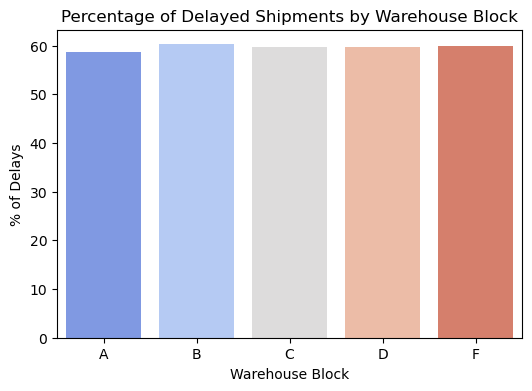

Warehouse_block
A    58.647027
B    60.229133
C    59.683579
D    59.760087
F    59.847245
Name: count, dtype: float64


In [19]:
warehouse_delay_rate = (
    df[df["Reached.on.Time_Y.N"] == 1]["Warehouse_block"].value_counts() / df["Warehouse_block"].value_counts()
) * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=warehouse_delay_rate.index, y=warehouse_delay_rate.values, hue=warehouse_delay_rate.index, palette="coolwarm", legend=False)
plt.title("Percentage of Delayed Shipments by Warehouse Block")
plt.ylabel("% of Delays")
plt.xlabel("Warehouse Block")
plt.show()

# Numerical values
print(warehouse_delay_rate)

# Does the importance of the product affect the delay?

Products with high importance experience significantly more delays (64.98%) compared to medium (59.04%) and low importance (59.28%) items. This suggests that high-priority products may face logistical challenges, possibly due to stricter handling requirements, specialized transportation, or supply chain constraints.

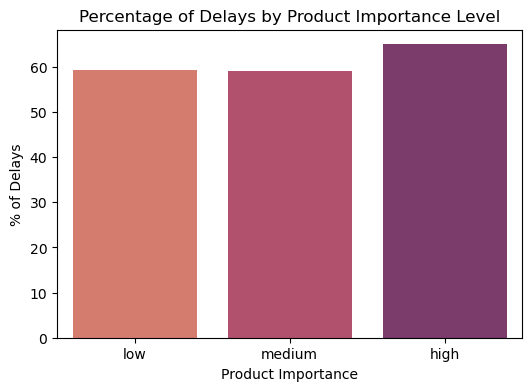

Product_importance
low       59.278837
medium    59.045015
high      64.978903
Name: count, dtype: float64


In [21]:
# Calculate the percentage of delayed shipments by product importance level
importance_delay_rate = (
    df[df["Reached.on.Time_Y.N"] == 1]["Product_importance"].value_counts() / df["Product_importance"].value_counts()
) * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=importance_delay_rate.index, y=importance_delay_rate.values, hue=importance_delay_rate.index, palette="flare", legend=False)
plt.title("Percentage of Delays by Product Importance Level")
plt.ylabel("% of Delays")
plt.xlabel("Product Importance")
plt.show()

# Nnumerical values
print(importance_delay_rate)

# Relationship between weight of goods and delays

The box plot suggests that delayed shipments (1) tend to have a wider range of product weights compared to on-time shipments (0). 

The median weight of delayed shipments appears lower than that of on-time shipments, and there are more extreme values (higher weight variation) among delayed shipments. 

This may indicate that lighter shipments are more prone to delays, or that variability in weight affects delivery performance.

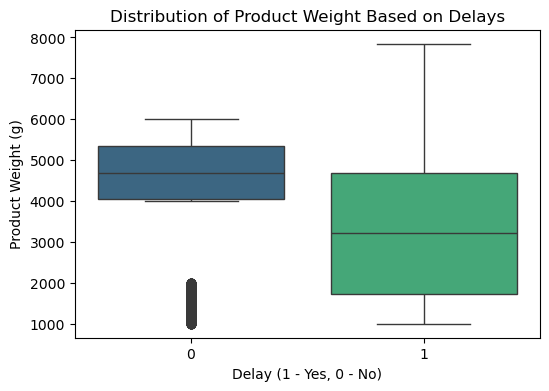

In [23]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Reached.on.Time_Y.N"], y=df["Weight_in_gms"], palette="viridis", hue=df["Reached.on.Time_Y.N"], legend=False)
plt.title("Distribution of Product Weight Based on Delays")
plt.xlabel("Delay (1 - Yes, 0 - No)")
plt.ylabel("Product Weight (g)")
plt.show()

# Analysis of the impact of a discount on lateness

The box plot indicates that delayed shipments (1) tend to have higher discount amounts compared to on-time shipments (0). 

The median discount for delayed shipments is notably higher, and there is a wider range of discount values. 

This suggests that higher discounts may be associated with an increased likelihood of shipment delays, possibly due to factors such as lower-priority processing for discounted orders.

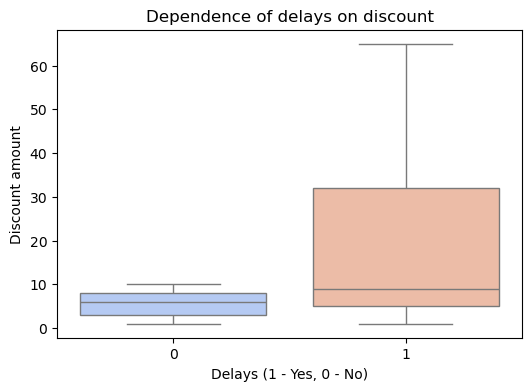

In [25]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Reached.on.Time_Y.N"], y=df["Discount_offered"], palette="coolwarm", hue=df["Reached.on.Time_Y.N"], legend=False)
plt.title("Dependence of delays on discount")
plt.xlabel("Delays (1 - Yes, 0 - No)")
plt.ylabel("Discount amount")
plt.show()

# Do more expensive items ship faster?

The box plot shows that there is no significant difference in product cost between delayed (1) and on-time (0) deliveries. 

Both distributions have similar medians and ranges, suggesting that more expensive items do not necessarily ship faster or slower. 

Price does not appear to be a strong factor influencing delivery delays.

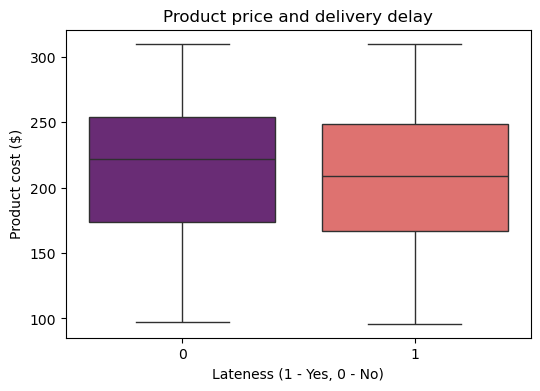

In [27]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Reached.on.Time_Y.N"], y=df["Cost_of_the_Product"], palette="magma", hue=df["Reached.on.Time_Y.N"], legend=False)
plt.title("Product price and delivery delay")
plt.xlabel("Lateness (1 - Yes, 0 - No)")
plt.ylabel("Product cost ($)")
plt.show()

# Is there a connection between customer ratings and lateness?

Difference isn't dramatic, and there's overlap in the distributions, indicating that factors beyond lateness also influence customer ratings.

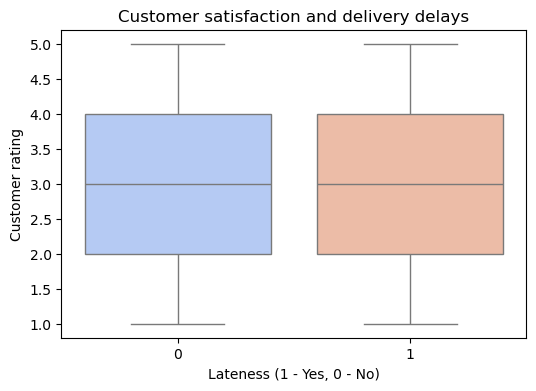

In [29]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Reached.on.Time_Y.N"], y=df["Customer_rating"], palette="coolwarm", hue=df["Reached.on.Time_Y.N"], legend=False)
plt.title("Customer satisfaction and delivery delays")
plt.xlabel("Lateness (1 - Yes, 0 - No)")
plt.ylabel("Customer rating")
plt.show()

# Conclusions:

 - ***Delays & Discounts:*** Higher discounts correlate with increased shipment delays. Lower-priority processing for discounted orders might be the cause.
- ***Customer Service Load:*** Expensive and discounted orders generate more customer service calls. Improving tracking systems could reduce inquiries.
- ***Warehouse & Shipment Efficiency:*** Most shipments pass through Warehouse Block F and use the Ship method. Delays are evenly distributed across warehouses and shipment methods, indicating broader operational inefficiencies.
- ***Product Importance & Delays:*** High-importance products experience more delays (64.98%), suggesting logistical bottlenecks for specialized handling.
- ***Weight Variability & Delays:*** Lighter shipments show a higher tendency for delays, possibly due to packaging, priority, or shipping constraints.
- ***Price vs. Shipping Speed:*** No strong correlation between product cost and delivery time—expensive items do not necessarily ship faster.
- ***Customer Satisfaction & Delays:*** While delays affect ratings, other factors (such as product quality and service) also contribute.

## Recommendations:
- ***Optimize Logistics for Discounted Orders:*** Reassess how discounted products are handled to minimize delays.
- ***Improve Customer Communication:*** Enhance shipment tracking and transparency to reduce customer service load.
- ***Analyze Warehouse & Shipment Processes:*** Investigate why Block F is dominant and whether alternative shipment methods (e.g., road, air) could improve efficiency.
- ***Prioritize High-Importance Products:*** Streamline the supply chain for critical products to reduce delays.
- ***Assess Weight-Based Logistics Challenges:*** Identify whether lightweight shipments require additional processing improvements.
- ***Enhance Customer Experience:*** Since delays impact ratings, consider loyalty programs or proactive customer service strategies to mitigate dissatisfaction.
